In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# El parámetro read_only=True permite abrirla aunque otro proceso la esté usando
con = duckdb.connect('../data/BaseDeDatos_Working.db', read_only=True)

In [22]:
import pandas as pd

# 1. Obtener la lista de tablas del esquema principal
tablas = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'").df()['table_name'].tolist()

print("="*70)
print(f"CLASIFICACIÓN ESTRUCTURAL DEL DATASET")
print("="*70)

for tabla in tablas:
    # Traemos el esquema de la tabla (solo 1 fila para no gastar memoria)
    df_temp = con.execute(f"SELECT * FROM main.{tabla} LIMIT 1").df()
    
    # Clasificación por tipos de Pandas
    v_texto = df_temp.select_dtypes(include=['object', 'category']).columns.tolist()
    v_num = df_temp.select_dtypes(include=['number']).columns.tolist()
    v_fecha = df_temp.select_dtypes(include=['datetime', 'datetime64', 'datetimetz']).columns.tolist()

    print(f"\nTABLA: {tabla.upper()}")
    
    if v_texto:
        print(f"   🔤 TEXTO/CATEGORÍA: {', '.join(v_texto)}")
    
    if v_num:
        print(f"   🔢 NUMÉRICAS:       {', '.join(v_num)}")
        
    if v_fecha:
        print(f"   📅 FECHAS:          {', '.join(v_fecha)}")
    
    print("-" * 40)

print("\n" + "="*70)
print("Clasificación finalizada.")

CLASIFICACIÓN ESTRUCTURAL DEL DATASET

TABLA: CAUSA
   🔤 TEXTO/CATEGORÍA: causa, causa_especifica
   🔢 NUMÉRICAS:       id_causa
----------------------------------------

TABLA: CLIMATOLOGIA
   🔤 TEXTO/CATEGORÍA: id_variable, id_clave_inc
   🔢 NUMÉRICAS:       id_registro, resultado_numerico
   📅 FECHAS:          fecha_de_observacion
----------------------------------------

TABLA: DANOS
   🔤 TEXTO/CATEGORÍA: id_clave_inc, tamanio
   🔢 NUMÉRICAS:       hojarasca, arbustivo, herbaceo, arbolado_adulto, renuevo
----------------------------------------

TABLA: DEMOGRAFIA
   🔤 TEXTO/CATEGORÍA: id_cvegeo, sexo
   🔢 NUMÉRICAS:       anio, pob_total, r_00_04, r_05_09, r_10_14, r_15_19, r_20_24, r_25_29, r_30_34, r_35_39, r_40_44, r_45_49, r_50_54, r_55_59, r_60_64, r_65_69, r_70_74, r_75_79, r_80_84, r_85_mm
----------------------------------------

TABLA: DICCIONARIO
   🔤 TEXTO/CATEGORÍA: id_variable, fuente, nombre_completo, unidad_de_medida
----------------------------------------

TABLA: E

In [23]:
import pandas as pd

tablas = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'").df()['table_name'].tolist()

print("="*80)
print(f"🕵️  INSPECCIÓN DE CAMPOS DE TEXTO PARA ESTRATEGIA DE LIMPIEZA")
print("="*80)

for tabla in tablas:
    # Obtenemos columnas de tipo texto (VARCHAR/STRING)
    cols_texto = con.execute(f"""
        SELECT column_name 
        FROM information_schema.columns 
        WHERE table_name = '{tabla}' AND data_type = 'VARCHAR'
    """).df()['column_name'].tolist()
    
    if cols_texto:
        print(f"\n📂 TABLA: {tabla.upper()}")
        # Tomamos una muestra para ver cómo lucen los datos actuales
        muestra = con.execute(f"SELECT {', '.join([f'\"{c}\"' for c in cols_texto])} FROM main.{tabla} LIMIT 5").df()
        display(muestra)
        print("-" * 80)

🕵️  INSPECCIÓN DE CAMPOS DE TEXTO PARA ESTRATEGIA DE LIMPIEZA

📂 TABLA: CAUSA


,causa,causa_especifica
0,intencional,cambio de uso de suelo
1,quema de basureros,basurero irregular
2,transportes,escapes
3,otras actividades productivas,lineas electricas
4,fumadores,fumadores


--------------------------------------------------------------------------------

📂 TABLA: CLIMATOLOGIA


,id_variable,id_clave_inc
0,T2M,15-15-0002
1,T2M,15-15-0002
2,T2M,15-15-0002
3,T2M,15-15-0002
4,T2M,15-15-0002


--------------------------------------------------------------------------------

📂 TABLA: DANOS


...

--------------------------------------------------------------------------------

📂 TABLA: OPERACIONES


,id_clave_inc
0,15-15-0010
1,15-15-0020
2,15-15-0021
3,15-15-0028
4,15-15-0030


--------------------------------------------------------------------------------

📂 TABLA: VEGETACION


,regimen_del_fuego,tipo_de_vegetacion
0,Otros,mezquital espinoso
1,Otros,matorral crasicaule
2,Adaptado,matorral espinoso tamaulipeco
3,Adaptado,pradera de alta montana
4,Otros,matorral sarco-crasicaule


--------------------------------------------------------------------------------


In [24]:
# Diagnóstico de Salud de los Datos (Sin borrar nada)
print("="*60)
print("🔎 REPORTE DE INCONSISTENCIAS LÓGICAS")
print("="*60)

# 1. Error de Tiempos
tiempos_err = con.execute("""
    SELECT COUNT(*) FROM main.operaciones o
    JOIN main.incendios i ON o.id_clave_inc = i.id_clave_inc
    WHERE o.fecha_termino < i.fecha_inicio 
       OR (o.fecha_termino = i.fecha_inicio AND o.hora_llegada < o.hora_deteccion)
""").fetchone()[0]

# 2. Error de Coordenadas
gps_err = con.execute("""
    SELECT COUNT(*) FROM main.incendios 
    WHERE latitud NOT BETWEEN 14 AND 33 OR longitud NOT BETWEEN -118 AND -86
""").fetchone()[0]

# 3. Error de Hectáreas
danos_err = con.execute("""
    SELECT COUNT(*) FROM main.danos 
    WHERE hojarasca < 0 OR arbustivo < 0 OR herbaceo < 0 OR arbolado_adulto < 0 OR renuevo < 0
""").fetchone()[0]

# 4. Error de Demografía
demo_err = con.execute("""
    SELECT COUNT(*) FROM main.demografia 
    WHERE pob_total <= 0
""").fetchone()[0]

print(f"⏰ Tiempos Imposibles:    {tiempos_err} registros")
print(f"📍 GPS fuera de rango:   {gps_err} registros")
print(f"🔥 Daños Negativos:      {danos_err} registros")
print(f"👥 Población Inválida:   {demo_err} registros")
print("="*60)

🔎 REPORTE DE INCONSISTENCIAS LÓGICAS
⏰ Tiempos Imposibles:    114 registros
📍 GPS fuera de rango:   0 registros
🔥 Daños Negativos:      0 registros
👥 Población Inválida:   0 registros


In [28]:
import pandas as pd

def inspeccionar_salud_estructural(con):
    print("="*85)
    print(f"🔍 DIAGNÓSTICO ESTRATÉGICO (IDs PROTEGIDOS)")
    print("="*85)

    # 1. Lista de nombres de columnas que funcionan como llaves (IDs)
    # Agregamos todas las que definiste en tu SQL
    ids_sagrados = [
        'id_clave_inc', 'id_cvegeo', 'id_variable', 'id_causa', 
        'id_vegetacion', 'id_clave_ent', 'id_registro'
    ]

    tablas_df = con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'").df()
    
    if tablas_df.empty:
        print("❌ No se encontraron tablas en 'main'.")
        return

    for tabla in tablas_df['table_name'].tolist():
        total_filas = con.execute(f"SELECT COUNT(*) FROM main.{tabla}").fetchone()[0]
        
        columnas_info = con.execute(f"""
            SELECT column_name, data_type 
            FROM information_schema.columns 
            WHERE table_name = '{tabla}'
        """).df()

        resultados = []

        for _, row in columnas_info.iterrows():
            col = row['column_name']
            tipo = row['data_type']
            tipo_up = tipo.upper()
            
            nulos = con.execute(f'SELECT COUNT(*) FROM main.{tabla} WHERE "{col}" IS NULL').fetchone()[0]
            porcentaje = round((nulos / total_filas) * 100, 2) if total_filas > 0 else 0
            
            # --- LÓGICA DE CLASIFICACIÓN REFINADA ---
            
            # 1. Prioridad: ¿Es una llave/ID?
            if col.lower() in ids_sagrados:
                accion = "🔒 ID Protegido (No tocar)"
            
            # 2. Si es texto descriptivo (y no es ID)
            elif 'VARCHAR' in tipo_up or 'STRING' in tipo_up:
                accion = "🏷️ Etiquetar ('no especificado')"
            
            # 3. Si es métrica numérica
            elif any(x in tipo_up for x in ['INT', 'FLOAT', 'DOUBLE', 'DECIMAL']):
                accion = "🔢 Preservar NULL (Métrica)"
            
            # 4. Si es tiempo o fecha
            elif any(x in tipo_up for x in ['DATE', 'TIME', 'TIMESTAMP', 'INTERVAL']):
                accion = "📅 Preservar NULL (Temporal)"
            else:
                accion = "❓ Revisar"

            resultados.append({
                'Columna': col,
                'Tipo SQL': tipo,
                'Nulos': nulos,
                '% Nulos': porcentaje,
                'Acción sugerida': accion
            })

        print(f"\n📂 TABLA: {tabla.upper()} | Registros: {total_filas}")
        print("-" * 85)
        df_reporte = pd.DataFrame(resultados)
        print(df_reporte.to_string(index=False))

# EJECUCIÓN
inspeccionar_salud_estructural(con)

🔍 DIAGNÓSTICO ESTRATÉGICO (IDs PROTEGIDOS)

📂 TABLA: CAUSA | Registros: 58
-------------------------------------------------------------------------------------
         Columna Tipo SQL  Nulos  % Nulos                  Acción sugerida
        id_causa  INTEGER      0      0.0        🔒 ID Protegido (No tocar)
           causa  VARCHAR      0      0.0 🏷️ Etiquetar ('no especificado')
causa_especifica  VARCHAR      0      0.0 🏷️ Etiquetar ('no especificado')

📂 TABLA: CLIMATOLOGIA | Registros: 11642996
-------------------------------------------------------------------------------------
             Columna Tipo SQL  Nulos  % Nulos             Acción sugerida
         id_registro   BIGINT      0      0.0   🔒 ID Protegido (No tocar)
         id_variable  VARCHAR      0      0.0   🔒 ID Protegido (No tocar)
        id_clave_inc  VARCHAR      0      0.0   🔒 ID Protegido (No tocar)
fecha_de_observacion     DATE      0      0.0 📅 Preservar NULL (Temporal)
  resultado_numerico    FLOAT      0  

In [2]:
import pandas as pd

def inspeccionar_climatologia_profunda(con):
    print("="*90)
    print("ANALISIS ESTRATEGICO DE LA TABLA CLIMATOLOGIA (11M+ REGISTROS)")
    print("="*90)

    # 1. Conteo general y salud de la tabla
    res_general = con.execute("""
        SELECT 
            COUNT(*) as total_registros,
            COUNT(DISTINCT id_variable) as total_variables,
            COUNT(*) FILTER (WHERE resultado_numerico IS NULL) as nulos_totales
        FROM main.climatologia
    """).df()
    
    print("\n--- RESUMEN GENERAL ---")
    print(res_general.to_string(index=False))

    # 2. Estadisticos descriptivos por variable
    # Esto es vital para definir los umbrales de neutralizacion
    print("\n--- DISTRIBUCION POR VARIABLE (LIMITES FISICOS) ---")
    stats_query = """
        SELECT 
            id_variable,
            COUNT(*) as registros,
            MIN(resultado_numerico) as min_valor,
            MAX(resultado_numerico) as max_valor,
            AVG(resultado_numerico) as promedio,
            STDDEV(resultado_numerico) as desv_std,
            COUNT(*) FILTER (WHERE resultado_numerico IS NULL) as nulos
        FROM main.climatologia
        GROUP BY id_variable
        ORDER BY registros DESC
    """
    df_stats = con.execute(stats_query).df()
    
    # Calculamos el porcentaje de nulos por variable
    df_stats['%_nulos'] = (df_stats['nulos'] / df_stats['registros'] * 100).round(2)
    
    print(df_stats.to_string(index=False))

    # 3. Deteccion de posibles valores "basura" (Outliers extremos)
    # Buscamos valores que se alejan mas de 4 desviaciones estandar
    print("\n--- ANALISIS DE VALORES EXTREMOS (POSIBLES ERRORES DE SENSOR) ---")
    for var in df_stats['id_variable'].unique():
        sub_stats = df_stats[df_stats['id_variable'] == var].iloc[0]
        umbral_superior = sub_stats['promedio'] + (4 * sub_stats['desv_std'])
        umbral_inferior = sub_stats['promedio'] - (4 * sub_stats['desv_std'])
        
        print(f"\nVariable: {var}")
        print(f"   Umbral sugerido (+/- 4 sigma): [{round(umbral_inferior, 2)} a {round(umbral_superior, 2)}]")
        
# Ejecucion de la inspeccion
inspeccionar_climatologia_profunda(con)

ANALISIS ESTRATEGICO DE LA TABLA CLIMATOLOGIA (11M+ REGISTROS)

--- RESUMEN GENERAL ---
 total_registros  total_variables  nulos_totales
        13907820              145              0

--- DISTRIBUCION POR VARIABLE (LIMITES FISICOS) ---
                id_variable  registros   min_valor   max_valor    promedio   desv_std  nulos  %_nulos
                PRECTOTCORR     193980    0.000000   46.049999    0.482795   1.292109      0      0.0
                 TOA_SW_DNI      97000   54.720001   66.500000   61.632011   1.906401      0      0.0
                  T2M_RANGE      97000    0.100000   23.209999   16.810601   2.809260      0      0.0
                  WS50M_MAX      97000    1.580000   19.770000    5.610887   1.544304      0      0.0
                 GWM_HEIGHT      97000 -999.000000 -999.000000 -999.000000   0.000000      0      0.0
               MIDDAY_INSOL      97000    5.270000   98.650002   81.371997  10.716138      0      0.0
                      SNODP      97000 -999.000

In [3]:
def investigar_diccionario_clima(con):
    print("\n--- DEFINICIONES Y UNIDADES DEL DICCIONARIO ---")
    query = """
        SELECT id_variable, nombre_completo, unidad_de_medida, fuente
        FROM main.diccionario
        WHERE id_variable IN (
            SELECT DISTINCT id_variable FROM main.climatologia
        )
        ORDER BY id_variable
    """
    df_dicc = con.execute(query).df()
    # Mostramos todo para analizarlo juntos
    import pandas as pd
    pd.set_option('display.max_colwidth', None)
    print(df_dicc.to_string(index=False))

investigar_diccionario_clima(con)


--- DEFINICIONES Y UNIDADES DEL DICCIONARIO ---
                id_variable                                               nombre_completo      unidad_de_medida              fuente
                    AIRMASS                                                      air mass           por definir                nasa
                  ALLSKY_KT                            all sky insolation clearness index           por definir                nasa
                 ALLSKY_NKT                 all sky normalized insolation clearness index           por definir                nasa
          ALLSKY_SFC_LW_DWN                  all sky surface longwave downward irradiance           por definir                nasa
           ALLSKY_SFC_LW_UP                    all sky surface longwave upward irradiance           por definir                nasa
        ALLSKY_SFC_PAR_DIFF                                   all sky surface diffuse par           por definir                nasa
        ALLSKY_SFC_PAR_DIRH

# Inspección para la estandarización de datos tipo texto 

- Eliminar acentos extraños en los textos.
- Convertir el formato a mayúsculas.
- Inspeccionar si existen valores con espacios invisibles.

In [ ]:
## ESTA CONSULTA BUSCARA EN TODA LA BASE DE DATOS LAS VARIABLES QUE VIENEN EN FORMATO DE TEXTO 
text_columns = con.execute("""
    SELECT table_name, column_name 
    FROM information_schema.columns 
    WHERE data_type = 'VARCHAR' 
      AND table_schema = 'main'
""").fetchall()

print(f"Auditando {len(text_columns)} columnas de texto...\n")

for table, col in text_columns:
    stats = con.execute(f"""
        SELECT 
            COUNT(*) as total,
            SUM(CASE WHEN "{col}" != TRIM("{col}") THEN 1 ELSE 0 END) as con_espacios,
            SUM(CASE WHEN regexp_matches("{col}", '[áéíóúÁÉÍÓÚüÜñÑ]') THEN 1 ELSE 0 END) as con_acentos_especiales,
            SUM(CASE WHEN "{col}" != UPPER("{col}") AND "{col}" != LOWER("{col}") THEN 1 ELSE 0 END) as mezcla_case
        FROM {table}
    """).fetchone()
    
    if stats[1] > 0 or stats[2] > 0 or stats[3] > 0:
        print(f"Tabla: {table} | Columna: {col}")
        print(f"   - Espacios extra (inicio/fin): {stats[1]}")
        print(f"   - Con acentos/caracteres: {stats[2]}")
        print(f"   - Mezcla Mayúsculas/Minúsculas: {stats[3]}")
        print("-" * 30)

Auditando 22 columnas de texto...

Tabla: diccionario | Columna: fuente
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 0
   - Mezcla Mayúsculas/Minúsculas: 3
------------------------------
Tabla: diccionario | Columna: nombre_completo
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 0
   - Mezcla Mayúsculas/Minúsculas: 146
------------------------------
Tabla: diccionario | Columna: unidad_de_medida
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 0
   - Mezcla Mayúsculas/Minúsculas: 146
------------------------------
Tabla: estado | Columna: estado
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 1
   - Mezcla Mayúsculas/Minúsculas: 1
------------------------------
Tabla: vegetacion | Columna: regimen_del_fuego
   - Espacios extra (inicio/fin): 0
   - Con acentos/caracteres: 0
   - Mezcla Mayúsculas/Minúsculas: 41
------------------------------


#### Codificar una funcion en transform para limpiar todo tipo de caracteres raros y estandarizarlos para que el modelo no se confunda 

# Toma de Decisiones

In [ ]:
#Buscar las relaciones entre las tablas

con = duckdb.connect('../data/BaseDeDatos_Working.db', read_only=True)

# 1. Consultamos el catálogo de llaves foráneas
# DuckDB guarda las relaciones en la tabla 'duckdb_constraints'
query_relaciones = """
    SELECT 
        table_name AS tabla_hija,
        constraint_column_names[1] AS columna_fk,
        referenced_table AS tabla_padre
    FROM duckdb_constraints
    WHERE constraint_type = 'FOREIGN KEY'
"""

relaciones_detectadas = con.execute(query_relaciones).fetchall()

# 2. Convertimos el resultado al formato que necesitamos para la auditoría
relaciones = []
print("🔍 RELACIONES DETECTADAS EN EL ESQUEMA:")
print(f"{'TABLA HIJA':<15} | {'COLUMNA FK':<15} | {'TABLA PADRE':<15}")
print("-" * 50)

for hija, fk, padre in relaciones_detectadas:
    # Como tus PK suelen llamarse igual que las FK, las mapeamos así:
    # Nota: Si una PK se llama diferente, DuckDB también nos lo puede decir
    relaciones.append((hija, fk, padre, fk)) 
    print(f"{hija:<15} | {fk:<15} | {padre:<15}")

# Ahora 'relaciones' ya no es una lista manual, ¡es dinámica!

🔍 RELACIONES DETECTADAS EN EL ESQUEMA:
TABLA HIJA      | COLUMNA FK      | TABLA PADRE    
--------------------------------------------------
climatologia    | id_variable     | diccionario    
climatologia    | id_clave_inc    | incendios      
danos           | id_clave_inc    | incendios      
demografia      | id_cvegeo       | municipios     
incendios       | id_cvegeo       | municipios     
incendios       | id_causa        | causa          
incendios       | id_vegetacion   | vegetacion     
municipios      | id_clave_ent    | estado         
operaciones     | id_clave_inc    | incendios      


## Huerfanos

In [ ]:
print(" INICIANDO AUDITORÍA DINÁMICA DE INTEGRIDAD...\n")
hay_problemas = False

for hija, fk, padre, pk in relaciones:
    query = f"""
        SELECT COUNT(*) 
        FROM main.{hija} h
        LEFT JOIN main.{padre} p ON h.{fk} = p.{pk}
        WHERE p.{pk} IS NULL AND h.{fk} IS NOT NULL
    """
    
    total_huerfanos = con.execute(query).fetchone()[0]
    
    if total_huerfanos > 0:
        hay_problemas = True
        print(f"TABLA: {hija:<12} | FK: {fk:<15} | HUÉRFANOS: {total_huerfanos}")
        
        # Obtenemos una muestra de los IDs que no existen en el padre
        muestras = con.execute(f"""
            SELECT DISTINCT h.{fk} 
            FROM main.{hija} h 
            LEFT JOIN main.{padre} p ON h.{fk} = p.{pk} 
            WHERE p.{pk} IS NULL LIMIT 3
        """).fetchall()
        print(f" IDs que no están en '{padre}': {[m[0] for m in muestras]}")
        print("-" * 60)
    else:
        print(f"TABLA: {hija:<12} | Relación con '{padre}' perfecta.")

if not hay_problemas:
    print("\nNo hay registros huérfanos.")
else:
    print("\nSe encontraron huérfanos. Necesitamos decidir si borrar o corregir.")

 INICIANDO AUDITORÍA DINÁMICA DE INTEGRIDAD...

TABLA: climatologia | Relación con 'diccionario' perfecta.
TABLA: climatologia | Relación con 'incendios' perfecta.
TABLA: danos        | Relación con 'incendios' perfecta.
TABLA: demografia   | Relación con 'municipios' perfecta.
TABLA: incendios    | Relación con 'municipios' perfecta.
TABLA: incendios    | Relación con 'causa' perfecta.
TABLA: incendios    | Relación con 'vegetacion' perfecta.
TABLA: municipios   | Relación con 'estado' perfecta.
TABLA: operaciones  | Relación con 'incendios' perfecta.

No hay registros huérfanos.


Nivel Crítico (climatologia): Aquí es donde más fallan los procesos ETL. Si un satélite mandó dos veces el mismo dato de temperatura para el mismo incendio, tus promedios se sesgan. Aquí sí es obligatorio limpiar.

Nivel Estructural (municipios, causa, vegetacion): Si estas tienen duplicados, tus JOINs van a crear un "efecto explosión" (una fila se convierte en dos al unir), duplicando artificialmente tus hectáreas quemadas.

Nivel de Hechos (incendios, danos): Si aquí hay duplicados, tu conteo de incendios anuales será mentira.

### Duplicados 

In [ ]:
tablas_a_revisar = {
    'climatologia': ['id_variable', 'id_clave_inc', 'fecha_de_observacion'],
    'danos': ['id_clave_inc'], # Aquí solo debería haber uno por incendio
    'demografia': ['id_cvegeo', 'anio', 'sexo'],
    'operaciones': ['id_clave_inc']
}
for tabla, columnas in tablas_a_revisar.items():
    cols_str = ", ".join(columnas)
    query = f"""
        SELECT {cols_str}, COUNT(*) as repeticiones
        FROM main.{tabla}
        GROUP BY {cols_str}
        HAVING repeticiones > 1
        LIMIT 5
    """
    res = con.execute(query).df()
    
    if not res.empty:
        print(f"TABLA: {tabla.upper()} -> ¡Se encontraron duplicados!")
        print(res)
    else:
        print(f"TABLA: {tabla.upper()} -> Sin duplicados.")

TABLA: CLIMATOLOGIA -> ¡Se encontraron duplicados!
   id_variable id_clave_inc fecha_de_observacion  repeticiones
0  PRECTOTCORR   15-15-0145           2015-02-22             2
1  PRECTOTCORR   15-15-0170           2015-02-23             2
2  PRECTOTCORR   15-15-0210           2015-03-05             2
3  PRECTOTCORR   15-15-0249           2015-03-17             2
4  PRECTOTCORR   15-15-0308           2015-04-11             2
TABLA: DANOS -> Sin duplicados.
TABLA: DEMOGRAFIA -> Sin duplicados.
TABLA: OPERACIONES -> Sin duplicados.


# Lógica Temporal (Por el momento no se limpian)

In [ ]:
import json
import requests
import pandas as pd
import os

# --- CONFIGURACIÓN DE RUTAS ---
# Ajusta esta ruta a la ubicación real de tu archivo en Jupyter
JSON_PATH = '/home/saul/Metodologia/IncendiosForestales/01_ExtraccionDeDatos/DatosNASA/raw/diccionario_verificado.json' 

def extraer_unidades_nasa():
    if not os.path.exists(JSON_PATH):
        print(f"Error: No se encontró el archivo en {JSON_PATH}")
        return

    # 1. Cargar tu diccionario local
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        diccionario_local = json.load(f)
    
    # Extraemos los IDs para consultar
    ids_variables = [v['id'] for v in diccionario_local]
    print(f"Leídas {len(ids_variables)} variables del diccionario local.\n")

    # 2. Consultar Metadatos a la NASA
    # Usamos el endpoint de 'system/manager' que es más rápido para metadatos puros
    url_metadata = "https://power.larc.nasa.gov/api/system/manager/parameters/"
    
    print("Consultando metadatos oficiales a la NASA...")
    try:
        response = requests.get(url_metadata, timeout=20)
        response.raise_for_status()
        nasa_metadata = response.json()
        
        datos_para_tabla = []

        # 3. Cruzar información
        for var_id in ids_variables:
            # Buscamos el ID en la respuesta de la NASA
            info_oficial = nasa_metadata.get(var_id.upper())
            
            if info_oficial:
                datos_para_tabla.append({
                    "ID": var_id,
                    "Nombre NASA": info_oficial.get('long_name'),
                    "Unidad": info_oficial.get('units'),
                    "Estado": "Verificado ✅"
                })
            else:
                datos_para_tabla.append({
                    "ID": var_id,
                    "Nombre NASA": "No encontrado",
                    "Unidad": "N/A",
                    "Estado": "Revisar (¿Es GEE?) ⚠️"
                })

        # 4. Mostrar resultados en Jupyter
        df_unidades = pd.DataFrame(datos_para_tabla)
        
        # Estilo para que se vea bien en Jupyter
        return df_unidades.style.set_properties(**{'text-align': 'left'})

    except Exception as e:
        print(f"Fallo en la conexión: {e}")

# Ejecutar la prueba
extraer_unidades_nasa()

In [ ]:
import pandas as pd

# 1. ¿Hay incendios que terminan antes de empezar?
# Comparamos fecha_inicio (tabla incendios) vs fecha_termino (tabla operaciones)
print("REVISANDO LÓGICA DE FECHAS...")
query_fechas = """
    SELECT i.id_clave_inc, i.fecha_inicio, o.fecha_termino
    FROM main.incendios i
    JOIN main.operaciones o ON i.id_clave_inc = o.id_clave_inc
    WHERE o.fecha_termino < i.fecha_inicio
"""
df_fechas_locas = con.execute(query_fechas).df()

# 2. ¿Hay brigadas que llegan antes de detectar el incendio?
# Comparamos hora_deteccion vs hora_llegada (en el mismo día)
print("🔍 REVISANDO LÓGICA DE HORARIOS...")
query_horas = """
    SELECT id_clave_inc, hora_deteccion, hora_llegada
    FROM main.operaciones
    WHERE hora_llegada < hora_deteccion
"""
df_horas_locas = con.execute(query_horas).df()

# Reporte de resultados
if df_fechas_locas.empty and df_horas_locas.empty:
    print("\n¡Cronología perfecta! Todo ocurre en el orden correcto.")
else:
    if not df_fechas_locas.empty:
        print(f"Se encontraron {len(df_fechas_locas)} registros con fechas invertidas.")
    if not df_horas_locas.empty:
        print(f"Se encontraron {len(df_horas_locas)} registros con horarios imposibles.")

REVISANDO LÓGICA DE FECHAS...
🔍 REVISANDO LÓGICA DE HORARIOS...
Se encontraron 136 registros con horarios imposibles.


In [ ]:
# Ver los registros donde el incendio "termina antes de empezar"
if not df_fechas_locas.empty:
    print("DETALLE DE FECHAS INVERTIDAS:")
    # Traemos también el municipio para ver si es un problema de una región específica
    detalle_fechas = con.execute("""
        SELECT i.id_clave_inc, m.nombre_municipio, i.fecha_inicio, o.fecha_termino
        FROM main.incendios i
        JOIN main.operaciones o ON i.id_clave_inc = o.id_clave_inc
        JOIN main.municipios m ON i.id_cvegeo = m.id_cvegeo
        WHERE o.fecha_termino < i.fecha_inicio
    """).df()
    print(display(detalle_fechas)) # display() se ve mejor que print() en Jupyter

In [ ]:
if not df_horas_locas.empty:
    print("\nDETALLE DE HORARIOS IMPOSIBLES:")
    detalle_horas = con.execute("""
        SELECT id_clave_inc, hora_deteccion, hora_llegada, duracion_hhmm
        FROM main.operaciones
        WHERE hora_llegada < hora_deteccion
    """).df()
    display(detalle_horas)


DETALLE DE HORARIOS IMPOSIBLES:


,id_clave_inc,hora_deteccion,hora_llegada,duracion_hhmm
0,15-15-0196,00:06:00,00:04:00,0 days 01:17:00
1,15-15-0245,00:25:00,00:20:00,0 days 03:20:00
2,17-15-0317,00:10:00,00:05:00,0 days 01:55:00
3,17-15-0717,00:15:00,00:10:00,0 days 02:35:00
4,18-15-0394,00:10:00,00:05:00,0 days 00:55:00
...,...,...,...,...
131,20-15-0151,00:02:00,00:01:00,0 days 01:52:00
132,21-15-0515,00:35:00,00:30:00,0 days 02:00:00
133,21-15-0586,01:10:00,00:20:00,0 days 05:30:00
134,23-15-0446,01:00:00,00:00:00,NaT


# Valores Numericos 

## Climatologia

Generando radiografía de 14 millones de datos (Muestra de 100k)...


/tmp/ipykernel_37767/4026106703.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='id_variable', y='resultado_numerico', data=df_sample, palette="Set2")


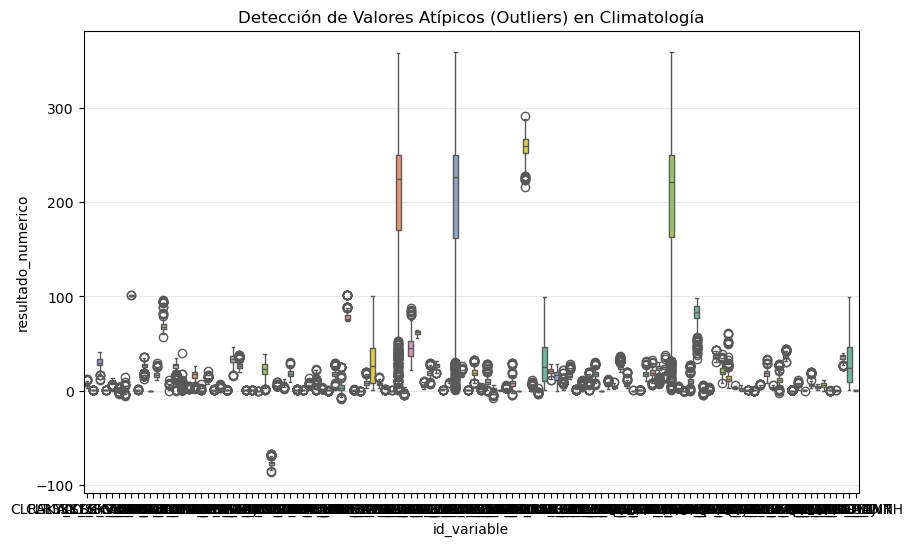

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generando radiografía de 14 millones de datos (Muestra de 100k)...")

# Tomamos una muestra para no saturar la memoria RAM
df_sample = con.execute("""
    SELECT resultado_numerico, id_variable 
    FROM main.climatologia 
    USING SAMPLE 100000;
""").df()

# Graficamos
plt.figure(figsize=(10, 6))
sns.boxplot(x='id_variable', y='resultado_numerico', data=df_sample, palette="Set2")
plt.title("Detección de Valores Atípicos (Outliers) en Climatología")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# Buscamos variables con valores imposibles
resumen_loco = con.execute("""
    SELECT id_variable, 
           MIN(resultado_numerico) as minimo, 
           MAX(resultado_numerico) as maximo,
           COUNT(*) FILTER (WHERE resultado_numerico <= -999) as total_nulos_codificados
    FROM main.climatologia
    GROUP BY id_variable
    HAVING minimo <= -999 OR maximo > 100
""").df()

print("Variables que necesitan limpieza :")
display(resumen_loco)

Variables que necesitan limpieza :


,id_variable,minimo,maximo,total_nulos_codificados
0,SLP,100.120003,102.250000,0
1,WD2M,0.100000,360.000000,0
2,WD50M,0.000000,360.000000,0
3,PS,73.900002,102.239998,0
4,TO3,215.880005,331.399994,0
5,WD10M,0.000000,359.899994,0


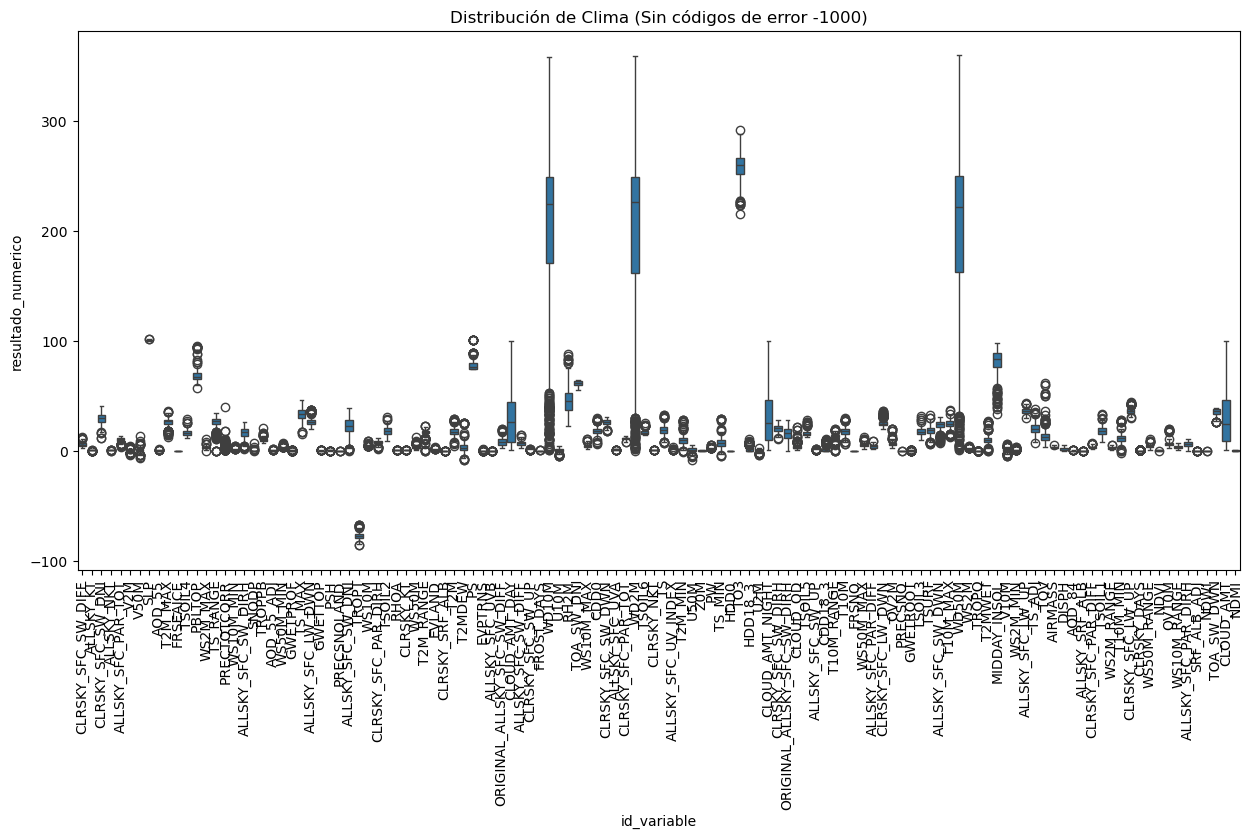

In [ ]:
# Filtramos los códigos de error para ver la distribución real
df_real = df_sample[df_sample['resultado_numerico'] > -500]

plt.figure(figsize=(15, 7))
sns.boxplot(x='id_variable', y='resultado_numerico', data=df_real)
plt.xticks(rotation=90) # Giramos los nombres para que no se encimen
plt.title("Distribución de Clima (Sin códigos de error -1000)")
plt.show()

In [ ]:
Codigos para el def 

def estandarizar_textos_global(con):
    print("   - [Transform] Estandarizando textos (Mayúsculas, acentos y espacios)...")
    
    # Este mapeo lo construimos gracias al auditor que corriste en Jupyter
    mapeo_limpieza = {
        'municipios': ['nombre_municipio'],
        'causa': ['causa', 'causa_especifica'],
        'vegetacion': ['tipo_de_vegetacion'],
        'incendios': ['tipo_de_incendio'],
        'danos': ['tamanio']
    }

    for tabla, columnas in mapeo_limpieza.items():
        for col in columnas:
            # Versión Ganadora: Regex + Lower + Trim
            query = f"""
                UPDATE {tabla} SET "{col}" = 
                LOWER(TRIM(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace(
                    regexp_replace("{col}", '[áÁ]', 'a', 'g'),
                                           '[éÉ]', 'e', 'g'),
                                           '[íÍ]', 'i', 'g'),
                                           '[óÓ]', 'o', 'g'),
                                           '[úÚüÜ]', 'u', 'g'),
                                           '[ñÑ]', 'n', 'g')
                ))
            """
            con.execute(query)
    print("   - [Transform] ¡Base de datos estandarizada para el modelo!")


# Identificamos las variables que son 100% basura
variables_basura = resumen_loco[resumen_loco['minimo'] == -999][resumen_loco['maximo'] == -999]['id_variable'].tolist()

print(f"Eliminando {len(variables_basura)} variables que no contienen información útil...")

# Borramos esos registros de la tabla
if variables_basura:
    con.execute(f"DELETE FROM main.climatologia WHERE id_variable IN ({str(variables_basura)[1:-1]})")
    # También hay que quitarlas del diccionario para que tu Cubo OLAP esté limpio
    con.execute(f"DELETE FROM main.diccionario WHERE id_variable IN ({str(variables_basura)[1:-1]})")

print("✅ Variables muertas eliminadas.")


# Borramos cualquier registro que tenga el código de error -999
con.execute("DELETE FROM main.climatologia WHERE resultado_numerico <= -999")

filas_restantes = con.execute("SELECT COUNT(*) FROM main.climatologia").fetchone()[0]
print(f"✅ Limpieza completada. Filas útiles restantes: {filas_restantes:,}")

# Ponemos en NULL las coordenadas que están fuera de los límites lógicos del Edomex
con.execute("""
    UPDATE main.incendios 
    SET latitud = NULL, longitud = NULL
    WHERE latitud NOT BETWEEN 18.3 AND 20.3
       OR longitud NOT BETWEEN -100.6 AND -98.5
       OR (latitud = 0 AND longitud = 0)
""")
print("✅ Coordenadas imposibles reseteadas a NULL.")

SyntaxError: invalid syntax (1689245942.py, line 1)

In [ ]:
# Coordenadas aproximadas del Estado de México
# Latitud: 18.3 a 20.3 | Longitud: -100.6 a -98.5
print("📍 Verificando que los incendios estén dentro del Estado de México...")
query_espacial = """
    SELECT id_clave_inc, latitud, longitud, m.nombre_municipio
    FROM main.incendios i
    JOIN main.municipios m ON i.id_cvegeo = m.id_cvegeo
    WHERE latitud NOT BETWEEN 18.3 AND 20.3
       OR longitud NOT BETWEEN -100.6 AND -98.5
"""
df_fuera_rango = con.execute(query_espacial).df()

if df_fuera_rango.empty:
    print("✅ Todos los incendios están dentro de los límites esperados.")
else:
    print(f"⚠️ Se encontraron {len(df_fuera_rango)} incendios con coordenadas sospechosas.")
    display(df_fuera_rango.head())


📍 Verificando que los incendios estén dentro del Estado de México...
⚠️ Se encontraron 116 incendios con coordenadas sospechosas.


,id_clave_inc,latitud,longitud,nombre_municipio
0,15-15-0188,0.000000,0.000000,Jocotitlán
1,15-15-0190,0.000000,0.000000,Zinacantepec
2,16-15-0410,0.000000,0.000000,Calimaya
3,16-15-0633,18.990473,-92.367889,Ocuilan
4,16-15-0826,0.000000,0.000000,Jocotitlán


In [ ]:
import pandas as pd

print("🔍 AUDITANDO TABLA DE DAÑOS (Hectáreas y consistencia)...")

# 1. Buscamos hectáreas negativas o totales exagerados (> 10,000 ha como alerta inicial)
query_danos_locos = """
    SELECT 
        d.id_clave_inc, 
        m.nombre_municipio,
        hojarasca, arbustivo, herbaceo, arbolado_adulto, renuevo,
        (hojarasca + arbustivo + herbaceo + arbolado_adulto + renuevo) AS total_calculado
    FROM main.danos d
    JOIN main.incendios i ON d.id_clave_inc = i.id_clave_inc
    JOIN main.municipios m ON i.id_cvegeo = m.id_cvegeo
    WHERE hojarasca < 0 OR arbustivo < 0 OR herbaceo < 0 OR arbolado_adulto < 0 OR renuevo < 0
       OR (hojarasca + arbustivo + herbaceo + arbolado_adulto + renuevo) > 10000
"""

df_danos_alertas = con.execute(query_danos_locos).df()

if df_danos_alertas.empty:
    print("✅ No se detectaron hectáreas negativas ni incendios mayores a 10,000 ha.")
else:
    print(f"⚠️ Se encontraron {len(df_danos_alertas)} registros con valores sospechosos.")
    display(df_danos_alertas)

🔍 AUDITANDO TABLA DE DAÑOS (Hectáreas y consistencia)...
✅ No se detectaron hectáreas negativas ni incendios mayores a 10,000 ha.
